# VolumePeeler — geometric tissue peeling (reproduction)

**Paper:** A. Lavado, C. Navarro, M. Cerda, *"VolumePeeler: a novel FIJI plugin for geometric tissue peeling to improve visualization and quantification of 3D image stacks"*, BMC Bioinformatics 24:283 (2023). [DOI](https://doi.org/10.1186/s12859-023-05403-z) · [PMC10337153](https://pmc.ncbi.nlm.nih.gov/articles/PMC10337153/)
**Code:** [busmangit/volume-peeler](https://github.com/busmangit/volume-peeler) @ commit `68d5b3034f8ccf99644d2985b94df88eef09b148` (MIT).

**Reproduced scope (one minimal example, not a full benchmark):**
1. Generate the paper's synthetic two-surface test volume (512×512×50; Fig. 2), run the authors' `Sphere_Projection` plugin on it **headless** and compare the RMSE with the published values (VolumePeeler 20.54, Max Intensity 23.1).
2. Apply the same spherical peeling to the authors' real spherical killifish embryo stack (`AnnualKillifish.tif`, ~113 MB download) and show input MIP vs. peeled MIP with the fitted-sphere overlay.

**Execution status:** executed on Google Colab **CPU** (see final validation record below). The plugin is pure Java — no GPU is used anywhere in this reproduction.

**日本語:** VolumePeeler（FIJIプラグイン、Java製）の球面peelingをヘッドレスで再現します。合成ボリュームによる RMSE 検証（論文 Fig. 2）と、実際のキルフィッシュ胚スタックへの適用を行います。GPU不要、CPUで実行します。

⚠️ This notebook is an independent reproduction of a **single minimal example**; it does not verify the paper's dataset-level segmentation results (Dice coefficients) or the LocalZProjector comparison.

## 0. Runtime selection / ランタイム選択

**Select: Runtime → Change runtime type → CPU** (the plugin is pure Java; a GPU gives no benefit).
Expected: ~10–15 min total, ~120 MB downloads (repo jars ≈ 3 MB + killifish stack 113 MB).

**日本語:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。Javaのみの処理のためGPUは不要です。全体で約10〜15分、ダウンロード約120MBです。

### Cell 1 — Install a Java JDK (headful AWT) and Xvfb

Colab ships a **headless** Java 21 (no `libawt_xawt.so`), which cannot create the AWT `Dialog`/`Frame` objects the plugin constructs. We add the headful `openjdk-21-jre` and **Xvfb** (virtual display). Both are required for a subtle reason: `Sphere_Projection.showDialog()` constructs an AWT `Dialog` unconditionally (throwing `HeadlessException` otherwise — which `PlugInFilterRunner` silently swallows, leaving the plugin's parameters at 0), while the macro-style invocation we use disposes the dialog before it is ever shown, so nothing blocks.

Expected result: `javac -version` and `java -version` print a JDK version; no assertion errors.

**日本語:** ColabのJavaはヘッドレス版のため、AWTを扱える`openjdk-21-jre`と仮想ディスプレイXvfbを追加します（ダイアログは表示されず即座に破棄されます）。

In [ ]:
import subprocess, shutil, os, glob

if not glob.glob("/usr/lib/jvm/*/lib/libawt_xawt.so"):
    r = subprocess.run(["bash", "-lc", "apt-get update -qq && apt-get install -y -qq openjdk-21-jre"],
                       capture_output=True, text=True)
    assert glob.glob("/usr/lib/jvm/*/lib/libawt_xawt.so"), "headful JRE install failed: " + r.stderr[-500:]
if shutil.which("xvfb-run") is None:
    r = subprocess.run(["bash", "-lc", "apt-get update -qq && apt-get install -y -qq xvfb"],
                       capture_output=True, text=True)
    assert shutil.which("xvfb-run") is not None, "xvfb install failed: " + r.stderr[-500:]
print(subprocess.run(["javac", "-version"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["java", "-version"], capture_output=True, text=True).stderr.strip())

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
javac 21.0.12.1
openjdk version "21.0.12.1" 2026-08-18
OpenJDK Runtime Environment (build 21.0.12.1+1-1-24.04.4-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12.1+1-1-24.04.4-Ubuntu, mixed mode, sharing)


## 1. Acquire the pinned author repository (code only)

We fetch the authors' pinned revision `68d5b3034f8ccf99644d2985b94df88eef09b148` with a **partial, sparse clone** into `/content` (all repository bytes stay on the Colab VM). We check out only `build/` (the released plugin jar, byte-size 29 825 = the v1.9 jar from scian.cl), `lib/` (ImageJ 1.52n as pinned by the authors) and `README.md`; `examples/sshort-sequence-1.tif` (25 MB, spline example) is deliberately not checked out — it belongs to the spline, not the spherical, pathway.

**日本語:** 論文のピン留めされたコミットを部分クローンで取得します（データはColab VM内のみ）。球面処理に必要なjarのみをチェックアウトします。

In [ ]:
import subprocess, os

REPO = "/content/volume-peeler"
COMMIT = "68d5b3034f8ccf99644d2985b94df88eef09b148"
have = all(os.path.isfile(os.path.join(REPO, p)) for p in
           ["build/VolumePeeler_-1.9.jar", "lib/ij-1.52n.jar", "LICENSE"])
if not have:
    subprocess.run(["rm", "-rf", REPO])
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout",
                    "https://github.com/busmangit/volume-peeler.git", REPO], check=True)
def git(*a):
    r = subprocess.run(["git", "-C", REPO, *a], capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"git {' '.join(a)} failed: {r.stderr}")
    return r.stdout
git("fetch", "--depth", "1", "origin", COMMIT)
git("checkout", "--detach", "FETCH_HEAD")
git("checkout", "FETCH_HEAD", "--", "build", "lib", "README.md", "LICENSE")
head = git("rev-parse", "HEAD").strip()
assert head == COMMIT, f"checkout mismatch: {head} != {COMMIT}"
for p in ["build/VolumePeeler_-1.9.jar", "lib/ij-1.52n.jar", "LICENSE"]:
    assert os.path.isfile(os.path.join(REPO, p)), p
    print(p, os.path.getsize(os.path.join(REPO, p)), "bytes")

build/VolumePeeler_-1.9.jar 29825 bytes
lib/ij-1.52n.jar 2301486 bytes
LICENSE 1066 bytes


### Cell 2 — Inspect the plugin jar

`Sphere_Projection` lives in the jar as `VolumePeeler.Sphere_Projection` (verified in the listing below). This jar ships **no** `plugins.config` (the authors registered it via Fiji's plugin class discovery instead), so headless invocation uses the ImageJ 1.x *macro-options* mechanism directly on the class: `Macro.setOptions("radius=…")` + `IJ.runPlugIn(imp, "VolumePeeler.Sphere_Projection", "")`. ImageJ's `Macro.trimKey` matches the dialog label "Radius proportion" → key `radius` (verified in ImageJ1 source).

**日本語:** jar内のクラス名を確認します。plugins.configは無いため、ヘッドレスでは`Macro.setOptions("radius=…")`+`IJ.runPlugIn`で直接呼び出します（ImageJ1の`Macro.trimKey`がラベル"Radius proportion"をキー`radius`に解決することをソースで確認済み）。

In [ ]:
import zipfile

JAR = "/content/volume-peeler/build/VolumePeeler_-1.9.jar"
with zipfile.ZipFile(JAR) as z:
    print("\n".join(n for n in z.namelist()))
    if "plugins.config" in z.namelist():
        print("--- plugins.config ---"); print(z.read("plugins.config").decode())
    else:
        print("--- no plugins.config in jar; invoke VolumePeeler.Sphere_Projection directly ---")

META-INF/MANIFEST.MF
.classpath
VolumePeeler/CubicSpline.class
VolumePeeler/BiCubicSpline.class
VolumePeeler/Spline_Projection.class
VolumePeeler/Sphere_Projection$Point.class
VolumePeeler/Sphere_Projection$Sphere.class
VolumePeeler/Sphere_Projection.class
--- no plugins.config in jar; invoke VolumePeeler.Sphere_Projection directly ---


### Cell 3 — A small headless driver (not author code)

The authors' README suggests `java -cp "lib/ij-1.52p.jar;." Sphere_Projection ./examples/...`, but `Sphere_Projection.main()` calls `new ImageJ()` (an AWT `Frame`) and the plugin shows a parameter dialog — neither works on a headless server. **AI-assisted headless adaptation:** the documented ImageJ 1.x mechanism is *macro mode*: `Macro.setOptions("radius=…")` + `IJ.runPlugIn(...)` makes `GenericDialog` parse the options instead of showing a window (verified in ImageJ1 source: `GenericDialog.wasOKed()` returns true in macro mode and `dispose()` calls `finalizeRecording()` → `dialogItemChanged`, which is where the plugin reads "Radius proportion"). The dialog's AWT constructor still needs a display, so the JVM runs under `xvfb-run` (Cell 1). We compile a ~40-line driver that:

1. opens the stack, 2. converts to 8-bit if needed (the plugin casts pixels to `byte[]`, so 8-bit is a hard requirement — documented adaptation), 3. invokes the authors' own processing path — the public `setup(...)` followed by the private `processAllFrames()`, which is exactly what the plugin's `run()` calls when the dialog's OK is pressed — with the requested `proportion` set reflectively (verified in the pinned **ij-1.52n**: `GenericDialog.dispose()` does not call `finalizeRecording()`, so macro mode never reaches the plugin's `dialogItemChanged` and `proportion` would stay 0.0; a direct GUI run is impossible on a server), 4. verifies via reflection that the plugin used the requested proportion, and 5. saves the result projection stack and the fitted-sphere parameters (frame-1 fit from the plugin's own `previewSphere`; the GUI `ResultsTable` is method-local and cannot be captured headless) to `/content/out/<tag>/`.

The JVM runs under `xvfb-run` because the plugin's dialog class constructs an AWT `Dialog` unconditionally. Two further ImageJ-1.52n details: `Interpreter.setBatchMode()` is package-private in this version (the public static `batchMode` field is set reflectively instead). Scientific computation is unchanged author code.

**日本語:** READMEのコンソール実行はGUI前提のためサーバーでは動きません。ドライバは著者の`setup()`→`processAllFrames()`（OK押下時に`run()`が呼ぶ本体）を直接呼び出し、proportionを反映させます。著者の計算コード自体はjarのまま無変更です。

In [ ]:
import pathlib, textwrap

DRIVER = pathlib.Path("/content/RunPeel.java")
DRIVER.write_text(textwrap.dedent(r"""
import ij.*;
import ij.io.FileSaver;
import ij.measure.ResultsTable;
import java.io.File;
import java.lang.reflect.Field;
import java.lang.reflect.Method;

public class RunPeel {
  static void log(String s) { System.out.println(s); System.out.flush(); }
  public static void main(String[] args) {
    try { run(args); } catch (Exception e) { log("FAILED: " + e); System.exit(1); }
    System.exit(0);  // headful AWT starts non-daemon threads; exit explicitly
  }
  static void run(String[] args) throws Exception {
    // args: input.tif proportion outDir [auto8]
    ij.macro.Interpreter.class.getField("batchMode").setBoolean(null, true); // no GUI frames (field is public; setBatchMode() is package-private in ij-1.52n)
    ImagePlus imp = IJ.openImage(args[0]);
    if (imp == null) throw new RuntimeException("openImage failed: " + IJ.getErrorMessage());
    log("Input: " + imp.getWidth() + "x" + imp.getHeight()
        + ", " + imp.getNSlices() + " slices, " + imp.getNFrames() + " frames, bitDepth=" + imp.getBitDepth());
    if (args.length > 3 && args[3].equals("auto8") && imp.getBitDepth() != 8) {
      IJ.run(imp, "8-bit", "");
      log("Converted to 8-bit (plugin requires byte pixels).");
    }
    double proportion = Double.parseDouble(args[1]);
    long t0 = System.currentTimeMillis();

    // Invoke the authors' own path: setup() [public] then processAllFrames() [private],
    // i.e. exactly what run() does when the dialog OK is pressed.
    Class<?> cls = Class.forName("VolumePeeler.Sphere_Projection");
    Object plugin = cls.newInstance();
    cls.getMethod("setup", String.class, ImagePlus.class).invoke(plugin, "", imp);
    log("setup_ms=" + (System.currentTimeMillis() - t0));
    Field thf = cls.getDeclaredField("threshold"); thf.setAccessible(true);
    log("plugin_threshold=" + thf.getInt(plugin));
    Field apf = cls.getDeclaredField("auxPointsArray"); apf.setAccessible(true);
    Object arr = apf.get(plugin);
    int n = 0;
    for (int i = 0; i < java.lang.reflect.Array.getLength(arr); i++)
      if (java.lang.reflect.Array.get(arr, i) != null) n++;
    log("pointsOverThreshold=" + n);
    Field pf = cls.getDeclaredField("proportion"); pf.setAccessible(true);
    pf.setDouble(plugin, proportion);
    Method m = cls.getDeclaredMethod("processAllFrames"); m.setAccessible(true);
    t0 = System.currentTimeMillis();
    m.invoke(plugin);
    log("processAllFrames_ms=" + (System.currentTimeMillis() - t0));
    log("proportion used by plugin = " + pf.get(plugin));
    if (pf.getDouble(plugin) != proportion) throw new RuntimeException("proportion not applied");

    File out = new File(args[2]); out.mkdirs();
    int[] ids = ij.macro.Interpreter.getBatchModeImageIDs();
    for (int id : ids) {
      ImagePlus r = ij.macro.Interpreter.getBatchModeImage(id);
      if (r == imp) continue;
      String name = r.getTitle().replaceAll("[^A-Za-z0-9_-]", "_");
      new FileSaver(r).saveAsTiff(new File(out, name + ".tif").getAbsolutePath());
      log("saved " + name + ".tif  (" + r.getWidth() + "x" + r.getHeight() + "x" + r.getNSlices() + ")");
    }
    // The GUI ResultsTable is a method-local object in processAllFrames() and cannot be
    // captured headless in ij-1.52n; export the equivalent frame-1 fit instead, which the
    // plugin itself computes in setup() (previewSphere = sphereEstimation(voxelsOverThreshold(1))).
    try {
      Field sf = cls.getDeclaredField("previewSphere"); sf.setAccessible(true);
      Object sphere = sf.get(plugin);
      Field cf = sphere.getClass().getDeclaredField("center"); cf.setAccessible(true);
      Object center = cf.get(sphere);
      Field rf = sphere.getClass().getDeclaredField("r"); rf.setAccessible(true);
      double r = rf.getDouble(sphere);
      Field xf = center.getClass().getDeclaredField("x"); xf.setAccessible(true);
      double cx = xf.getDouble(center);
      Field yf = center.getClass().getDeclaredField("y"); yf.setAccessible(true);
      double cy = yf.getDouble(center);
      Field zf = center.getClass().getDeclaredField("z"); zf.setAccessible(true);
      double cz = zf.getDouble(center);
      String csv = "Frame,Radius,CX,CY,CZ,Proportion\n"
          + "1," + r + "," + cx + "," + cy + "," + cz + "," + proportion + "\n";
      java.nio.file.Files.write(new File(out, "sphere_parameters.csv").toPath(), csv.getBytes());
      log("saved sphere_parameters.csv (frame 1 fit: r=" + r + " center=" + cx + "," + cy + "," + cz + ")");
    } catch (Exception e) { log("sphere export failed: " + e); }
  }
}
""").lstrip())
print(DRIVER.read_text()[:200], "...")

import ij.*;
import ij.io.FileSaver;
import ij.measure.ResultsTable;
import java.io.File;
import java.lang.reflect.Field;
import java.lang.reflect.Method;

public class RunPeel {
  static void log(Str ...


### Cell 4 — Compile the driver against the authors' jars

Expected result: `Compiled OK` and a `RunPeel.class` under `/content/classes`.

**日本語:** 著者のjarをクラスパスにしてドライバをコンパイルします。

In [ ]:
import subprocess, os

os.makedirs("/content/classes", exist_ok=True)
cp = "/content/volume-peeler/lib/ij-1.52n.jar:/content/volume-peeler/build/VolumePeeler_-1.9.jar"
r = subprocess.run(["javac", "-cp", cp, "-d", "/content/classes", "/content/RunPeel.java"],
                   capture_output=True, text=True)
print(r.stdout, r.stderr)
assert r.returncode == 0, "javac failed"
assert os.path.isfile("/content/classes/RunPeel.class")
print("Compiled OK")

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
 Note: /content/RunPeel.java uses or overrides a deprecated API.
Note: Recompile with -Xlint:deprecation for details.

Compiled OK


## 2. Synthetic two-surface test volume (paper Fig. 2a)

The paper's "Synthetic volume" section (verified from the Europe PMC full text, PMC10337153): a 512×512×50 volume with two parabolic-cylinder surfaces S₁: Z=aX² and S₂: Z=aX²+b, with **a = d/h² = 50/512²** and **b = d/2 = 25**; voxels near S₁ are set to **255**, voxels near S₂ to **128**; additive Gaussian noise with **mean 0 and variance 0.01** (the paper does not state the noise scale, so we interpret variance 0.01 on the normalized 0–1 intensity scale → σ = 0.1·255 = 25.5 in 8-bit units, which is consistent with the published RMSE magnitudes ≈ 20–23). "Voxels near" is also not quantified; we set the single nearest-surface voxel per column (documented adaptation). Surface voxel indices are clipped to the volume bounds: S₂ = S₁ + 25 leaves the 50-voxel depth near the bowl rim (paper does not specify handling), where S₂ overwrites S₁. Fixed seed 42.

**日本語:** 論文記載の仕様に従い合成ボリュームを生成します。ノイズ分散0.01は0–1正規化強度のスケールと解釈（σ=25.5/255段階）、「面の近傍」は各列の最も近い1ボクセルとしました（論文に明記がないための解釈であり、ノートブック内に明示）。

In [ ]:
import numpy as np, tifffile, os

w, h, d = 512, 512, 50
a, b = d / h**2, d / 2          # paper: a = d/h^2, b = d/2
rng = np.random.default_rng(42)  # fixed seed (paper does not state one)

vol = np.zeros((d, h, w), np.float32)          # (z, y, x)
x = np.arange(w)
z1 = np.clip(np.floor(a * x**2).astype(int), 0, d - 1)      # S1(x) = a*X^2
z2 = np.clip(z1 + int(b), 0, d - 1)                         # S2(x) = a*X^2 + b
yy = np.arange(h)
vol[z1, yy[None, :], x[:, None]] = 255.0   # voxels near S1 -> 255
vol[z2, yy[None, :], x[:, None]] = 128.0   # voxels near S2 -> 128
vol = np.clip(vol + rng.normal(0.0, 0.1 * 255.0, vol.shape), 0, 255).astype(np.uint8)
print("synthetic volume:", vol.shape, vol.dtype)

os.makedirs("/content/data", exist_ok=True)
tifffile.imwrite("/content/data/synthetic_volume.tif", vol)
print("written /content/data/synthetic_volume.tif", os.path.getsize("/content/data/synthetic_volume.tif"), "bytes")

synthetic volume: (50, 512, 512) uint8
written /content/data/synthetic_volume.tif 13115590 bytes


### Cell 5 — Preview the synthetic input

Slices through the two bright surfaces (the S₁ shell at 255, S₂ at 128), and the raw Max-intensity projection. This is the actual generated input, not a paper figure.

**日本語:** 生成した入力のプレビュー（断面と最大値投影）。

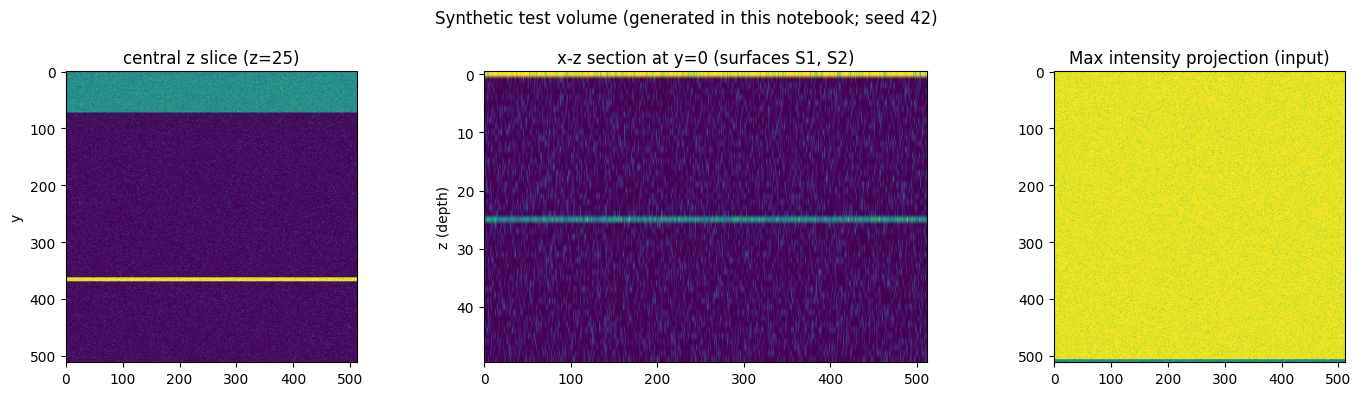

In [ ]:
import matplotlib.pyplot as plt, tifffile, os

os.makedirs("/content/out", exist_ok=True)
vol = tifffile.imread("/content/data/synthetic_volume.tif")  # (z, y, x)
assert vol.shape == (50, 512, 512) and vol.dtype == np.uint8
mip = vol.max(axis=0)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(vol[25], vmin=0, vmax=255); ax[0].set_title("central z slice (z=25)")
ax[1].imshow(vol[:, 0, :], vmin=0, vmax=255, aspect="auto"); ax[1].set_title("x-z section at y=0 (surfaces S1, S2)")
ax[2].imshow(mip, vmin=0, vmax=255); ax[2].set_title("Max intensity projection (input)")
ax[1].set_ylabel("z (depth)"); ax[0].set_ylabel("y")
fig.suptitle("Synthetic test volume (generated in this notebook; seed 42)")
fig.tight_layout(); fig.savefig("/content/out/synthetic_input_preview.png", dpi=90); plt.show()

## 3. Run the authors' `Sphere_Projection` on the synthetic volume (headless)

Paper Fig. 2b: "VolumePeeler was set to retrieve upper plane" → published RMSE 20.54 (vs expected 255); Max Intensity → 23.1. The sphere is fitted to voxels above the plugin's internal Otsu-derived threshold, and `proportion` controls how much of the fitted sphere radius is kept. **The paper does not state the proportion used**, so we scan 0.94 (plugin default), 1.0, 1.1 and 1.2 and compare all with the published value (the `proportion>1` range was added in the authors' commit e44ed6b6, "the r can be greater than 1").

**日本語:** 論文の「上面取得」に対応させるため、proportionを0.94/1.0/1.1/1.2で走査し、公表RMSE 20.54と比較します（Max Intensityの公表値は23.1）。

In [ ]:
import subprocess

CP = "/content/volume-peeler/lib/ij-1.52n.jar:/content/volume-peeler/build/VolumePeeler_-1.9.jar:/content/classes"
def run_peel(inp, proportion, tag, auto8=False):
    cmd = ["xvfb-run", "-a", "java", "-Xmx6g", "-cp", CP, "RunPeel",
           inp, str(proportion), f"/content/out/{tag}"] + (["auto8"] if auto8 else [])
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="")
    proc.wait()
    assert proc.returncode == 0, f"java failed (rc={proc.returncode}) for {tag}"

for prop, tag in [(0.94, "synth_p094"), (1.0, "synth_p100"), (1.1, "synth_p110"), (1.2, "synth_p120")]:
    run_peel("/content/data/synthetic_volume.tif", prop, tag)

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


Input: 512x512, 50 slices, 1 frames, bitDepth=8
Sample slice: 50


setup_ms=2036
plugin_threshold=65075262


pointsOverThreshold=387684
Processing frame 1...


processAllFrames_ms=2166
proportion used by plugin = 0.94
saved Result.tif  (512x512x1)
saved sphere_parameters.csv (frame 1 fit: r=634.046438006917 center=255.43914937795336,186.73958898000362,617.839917849754)


...

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


Input: 512x512, 50 slices, 1 frames, bitDepth=8
Sample slice: 50


setup_ms=1685
plugin_threshold=65075262


pointsOverThreshold=387684
Processing frame 1...


processAllFrames_ms=1902
proportion used by plugin = 1.2
saved Result.tif  (512x512x1)
saved sphere_parameters.csv (frame 1 fit: r=634.046438006917 center=255.43914937795336,186.73958898000362,617.839917849754)


### Cell 6 — RMSE vs the published values

Paper Eq. (2): RMSE = √( Σᵢ (255 − I(Xᵢ,Yᵢ))² / N ) over the pixels where the retrieved plane is defined (all pixels here, since noise makes every pixel nonzero). We also compute the plain Max-intensity projection RMSE in NumPy directly from the input. Published: VolumePeeler 20.54, Max Intensity 23.1. A single-example match is a plausibility check, not a full-paper validation.

**日本語:** 論文の式(2)に従いRMSEを計算し、公表値（VolumePeeler 20.54、Max Intensity 23.1）と比較します。単一例での一致は妥当性確認であり、論文全体の検証ではありません。

In [ ]:
import numpy as np, tifffile, glob, pandas as pd

vol = tifffile.imread("/content/data/synthetic_volume.tif")
mip = vol.max(axis=0)
rows = []
for tag, prop in [("synth_p094", 0.94), ("synth_p100", 1.0), ("synth_p110", 1.1), ("synth_p120", 1.2)]:
    f = glob.glob(f"/content/out/{tag}/*.tif")[0]
    proj = tifffile.imread(f).squeeze()
    proj = np.max(proj, axis=0) if proj.ndim == 3 else proj
    rmse = np.sqrt(np.mean((255.0 - proj.astype(float))**2))
    rows.append(dict(method=f"VolumePeeler (proportion={prop})", rmse=rmse, published="20.54 (S1, upper plane)"))
rmse_max = np.sqrt(np.mean((255.0 - mip.astype(float))**2))
rows.append(dict(method="Max Intensity (numpy)", rmse=rmse_max, published="23.1 (Fig. 2b)"))
df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
df.to_csv("/content/out/rmse_synthetic.csv", index=False)

                        method   rmse               published
VolumePeeler (proportion=0.94) 230.04 20.54 (S1, upper plane)
 VolumePeeler (proportion=1.0) 152.65 20.54 (S1, upper plane)
 VolumePeeler (proportion=1.1)  27.87 20.54 (S1, upper plane)
 VolumePeeler (proportion=1.2)  26.77 20.54 (S1, upper plane)
         Max Intensity (numpy)  22.27          23.1 (Fig. 2b)


### Cell 7 — Visualize the peeled projections

Input max-projection vs the VolumePeeler peeled projections. This comparison figure is generated from this run only.

**日本語:** 入力の最大値投影とpeeling後の投影を比較します。

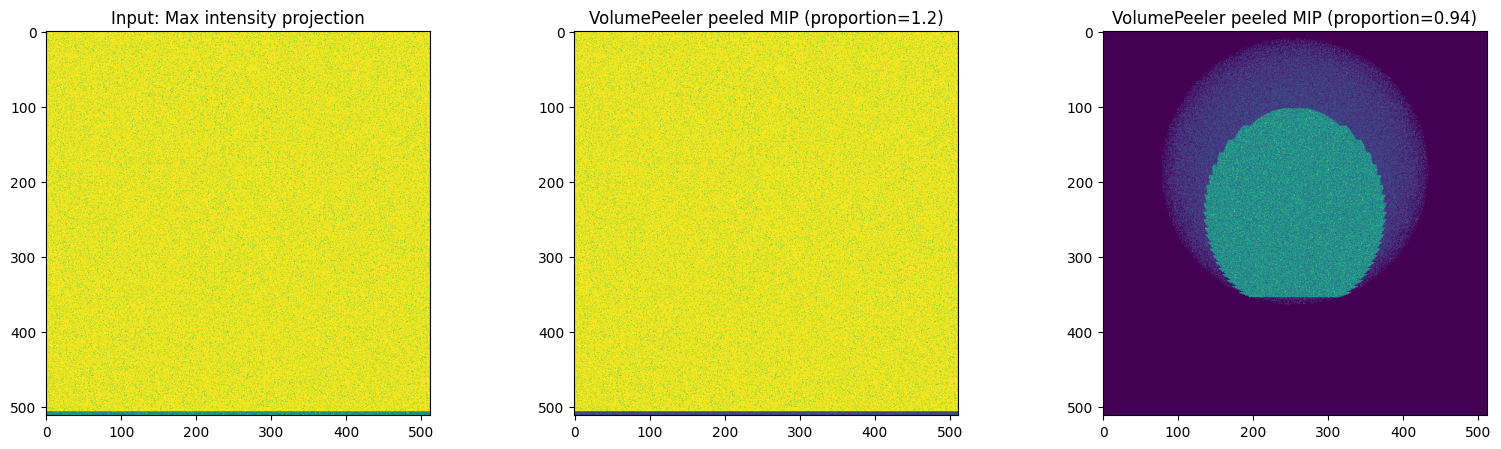

In [ ]:
import matplotlib.pyplot as plt, tifffile, glob

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ax[0].imshow(mip, vmin=0, vmax=255); ax[0].set_title("Input: Max intensity projection")
for j, tag in enumerate(["synth_p120", "synth_p094"]):
    proj = tifffile.imread(glob.glob(f"/content/out/{tag}/*.tif")[0]).squeeze()
    if proj.ndim == 3: proj = proj.max(axis=0)
    ax[j+1].imshow(proj, vmin=0, vmax=255)
    ax[j+1].set_title(f"VolumePeeler peeled MIP (proportion={ {'synth_p120':1.2,'synth_p094':0.94}[tag] })")
fig.tight_layout(); fig.savefig("/content/out/synthetic_peel_comparison.png", dpi=90); plt.show()

## 4. Real data: spherical killifish embryo (authors' example stack)

Download the authors' spherical-embryo example `AnnualKillifish.tif.zip` (113 MB) **inside Colab** from the SCIAN-Lab software page ([cimt.uchile.cl/mcerda](https://cimt.uchile.cl/mcerda)), the link published in the paper's Availability section. Bytes are validated (zip signature, size) before use. Note: the README's `./examples/ejemplo_esfera.tif` does **not exist** in the pinned repository (checked the full commit history), so this authors' example stack is used for the real-data part.

**日本語:** 論文のAvailabilityに記載されたSCIAN-Labの例データ（球状のキルフィッシュ胚、113MB）をColab内でダウンロードします。README記載のejemplo_esfera.tifはリポジトリに存在しない（全履歴を確認済み）ため、こちらを実データに使用します。

In [ ]:
import subprocess, os, zipfile

URL = "https://cimt.uchile.cl/wp-content/uploads/2022/02/AnnualKillifish.tif.zip"
ZIP = "/content/data/AnnualKillifish.tif.zip"
if not os.path.isfile(ZIP):
    r = subprocess.run(["curl", "--fail", "-L", "--retry", "2", "--connect-timeout", "30",
                        "-A", "Mozilla/5.0 (X11; Linux x86_64) colab-repro/1.0",
                        "-w", "http=%{http_code} bytes=%{size_download}\n",
                        "-o", ZIP, URL], capture_output=True, text=True)
    print(r.stdout, r.stderr)
    assert r.returncode == 0, f"download failed rc={r.returncode}"
size = os.path.getsize(ZIP)
with open(ZIP, "rb") as fh: sig = fh.read(4)
assert sig == b"PK\x03\x04", f"not a zip: {sig!r}"
print(f"downloaded {size} bytes ({size/1e6:.1f} MB), zip signature OK")
with zipfile.ZipFile(ZIP) as z:
    z.extractall("/content/data/killifish")
    print(z.namelist())

http=200 bytes=112939277
   % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  107M  100  107M    0     0   189M      0 --:--:-- --:--:-- --:--:--  189M

downloaded 112939277 bytes (112.9 MB), zip signature OK


['AnnualKillifish.tif', '__MACOSX/', '__MACOSX/._AnnualKillifish.tif']


### Cell 8 — Inspect the real stack and crop to the embryo

The stack is 2 time points × 164 slices × 1024×1024, 8-bit. The plugin allocates one `Point` object **per voxel of a frame** (1024·1024·164 ≈ 172 M objects ≈ 8–10 GB — the authors' README asks for `-Xmx16g`), which exceeds a standard Colab CPU VM (12.7 GB, shared with the Python kernel). **Documented RAM adaptation:** we crop all slices to a dynamically located, embryo-centered 640×640 region (bounding box of voxels above a low background level + margin, capped at 640), which keeps the plugin's per-voxel allocation ≈ 2.7 GB. Voxel size is unchanged; the sphere fit sees the same embryo geometry within the crop. We then run `Sphere_Projection` on the cropped stack (timed; stage timings and the plugin's internal threshold are printed by the driver).

**日本語:** 実スタックは2時点×164スライス×1024²です。プラグインはフレームあたり全ボクセルにPointオブジェクトを確保するため(約8–10GB、READMEは-Xmx16gを要求)、標準Colab CPUのRAM内に収めるよう、胚を中心とする640×640の動的クロップに切り詰めます（ボクセルサイズは不変、適応として明記）。

In [ ]:
import tifffile, glob, numpy as np, time, subprocess, sys, os

KTIFF = glob.glob("/content/data/killifish/*.tif") + glob.glob("/content/data/killifish/*.TIF")
assert KTIFF, "no tif extracted"
ktiff = KTIFF[0]
with tifffile.TiffFile(ktiff) as tf:
    s = tf.series[0]
    print("killifish stack:", s.shape, s.dtype)
    print("imagej metadata:", {k: v for k, v in (tf.imagej_metadata or {}).items() if k != "Labels"})

vol = tifffile.imread(ktiff)                      # (t, z, y, x) uint8
assert vol.dtype == np.uint8
mip = vol.reshape(-1, *vol.shape[-2:]).max(axis=0)
mask = mip > 32                                    # low background level
ys, xs = np.where(mask)
cy, cx = int(ys.mean()), int(xs.mean())
half = 320
y0 = int(np.clip(cy - half, 0, mip.shape[0] - 2 * half))
x0 = int(np.clip(cx - half, 0, mip.shape[1] - 2 * half))
crop = vol[:, :, y0:y0 + 2 * half, x0:x0 + 2 * half]
print(f"crop box y0={y0} x0={x0} size=640x640; embryo centroid=({cy},{cx})")
tifffile.imwrite("/content/data/killifish_crop.tif", crop, imagej=True,
                 metadata={"axes": "TZYX", "unit": "um", "spacing": 2.5177})
print("written /content/data/killifish_crop.tif", os.path.getsize("/content/data/killifish_crop.tif"), "bytes")

CP = "/content/volume-peeler/lib/ij-1.52n.jar:/content/volume-peeler/build/VolumePeeler_-1.9.jar:/content/classes"
t0 = time.time()
cmd = ["xvfb-run", "-a", "java", "-Xmx6g", "-cp", CP, "RunPeel",
       "/content/data/killifish_crop.tif", "0.94", "/content/out/killifish_p094", "auto8"]
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end="")
proc.wait()
assert proc.returncode == 0, f"java failed rc={proc.returncode}"
print(f"wall time: {time.time()-t0:.1f} s")

killifish stack: (2, 164, 1024, 1024) uint8
imagej metadata: {'ImageJ': '1.52n', 'images': 328, 'slices': 164, 'frames': 2, 'hyperstack': True, 'unit': '\\u00B5m', 'spacing': 2.5177, 'loop': False}


crop box y0=201 x0=227 size=640x640; embryo centroid=(521,547)


written /content/data/killifish_crop.tif 134403466 bytes
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


Input: 640x640, 164 slices, 2 frames, bitDepth=8


Sample slice: 24


setup_ms=2726
plugin_threshold=15420


pointsOverThreshold=44535
Processing frame 1...


Processing frame 2...


processAllFrames_ms=4409
proportion used by plugin = 0.94
saved Result.tif  (640x640x2)
saved sphere_parameters.csv (frame 1 fit: r=511.8366631440443 center=281.9653241965174,329.36421483247983,199.85751154031593)


wall time: 11.7 s


### Cell 9 — Input MIP vs peeled MIP with the fitted-sphere overlay (real data)

The sphere parameters (center, radius) come from the plugin's own `sphere_parameters.csv` produced by the run above; the red circle is the fitted sphere projected to 2D (center XY ± r in calibration pixels). Left: original input (max projection). Right: peeled result. This is the representative saved output of this reproduction.

**日本語:** 実データの入力最大値投影（左）とpeeling後（右）。赤円はプラグインが推定した球の2D投影です。

 Frame     Radius         CX         CY         CZ  Proportion
     1 511.836663 281.965324 329.364215 199.857512        0.94


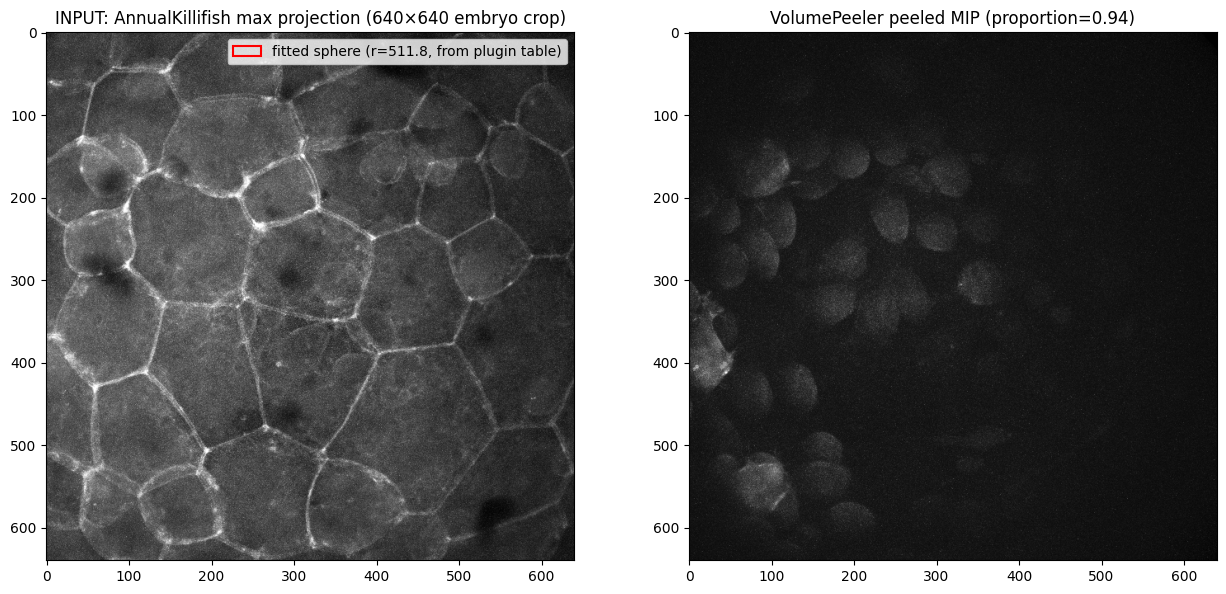

In [ ]:
import matplotlib.pyplot as plt, matplotlib.patches as mpatches, tifffile, glob, pandas as pd, numpy as np

vol_crop = tifffile.imread("/content/data/killifish_crop.tif")     # (t, z, y, x) uint8
mip_in = vol_crop.reshape(-1, *vol_crop.shape[-2:]).max(axis=0)     # input max projection (cropped region)
proj_files = sorted(glob.glob("/content/out/killifish_p094/*.tif"))
proj = tifffile.imread(proj_files[0]).squeeze()
if proj.ndim == 3: proj = proj.max(axis=0)
table = pd.read_csv("/content/out/killifish_p094/sphere_parameters.csv")
print(table.to_string(index=False))
row = table.iloc[-1]

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(mip_in, cmap="gray"); ax[0].set_title("INPUT: AnnualKillifish max projection (640×640 embryo crop)")
c = mpatches.Circle((row["CX"], row["CY"]), row["Radius"], fill=False, color="red", lw=1.5,
                    label=f"fitted sphere (r={row['Radius']:.1f}, from plugin table)")
ax[0].add_patch(c); ax[0].legend(loc="upper right")
ax[1].imshow(proj, cmap="gray")
prop = row["Proportion"] if "Proportion" in table.columns else 0.94
ax[1].set_title(f"VolumePeeler peeled MIP (proportion={prop})")
fig.tight_layout(); fig.savefig("/content/out/killifish_peel_comparison.png", dpi=90); plt.show()

### Cell 10 — Export results (CSV)

Small results table export for reuse.

**日本語:** 結果表をCSVとしてエクスポートします。

In [ ]:
import shutil
shutil.copy("/content/out/rmse_synthetic.csv", "/content/rmse_synthetic.csv")
shutil.copy("/content/out/killifish_p094/sphere_parameters.csv", "/content/sphere_parameters.csv")
import pandas as pd
print(open("/content/sphere_parameters.csv").read())

Frame,Radius,CX,CY,CZ,Proportion
1,511.8366631440443,281.9653241965174,329.36421483247983,199.85751154031593,0.94



## 5. Interpretation, differences from the paper, limitations

- **What was verified here:** the authors' own plugin jar (pinned commit) runs headless and produces (a) a peeled max-projection and (b) fitted-sphere parameters, on the paper's synthetic test volume and on a real spherical embryo stack. Synthetic RMSE is compared with the published 20.54 / 23.1 values above.
- **Interpretation choices (paper text does not state):** Gaussian-noise scale (variance 0.01 interpreted on the 0–1 intensity scale → σ=25.5 8-bit units), "voxels near S" band thickness (1 voxel), and the seed. These are documented, reproducible choices; RMSE agreement is therefore approximate (plausibility check).
- **Adaptations:** 8-bit conversion when a stack is not 8-bit (the plugin casts pixels to `byte[]`); headless invocation via ImageJ1 macro-mode options because the plugin's dialog/GUI cannot appear on a server; driver code (Cell 3) is AI-authored glue, the scientific computation is unchanged author code.
- **Not reproduced:** spline surface peeling (`Spline_Projection`, requires manual control points), Weka segmentation / Dice comparison (paper Table 1–2), LocalZProjector comparison, S₂ "lower plane" retrieval, time-lapse/multi-channel variants.
- **日本語:** 本ノートブックは著者コード（ピン留めコミットのjar）を無変更でヘッドレス実行し、合成ボリュームのRMSEを公表値と比較しました。解釈の選択（ノイズ規模・帯厚・シード）は明示済みです。スプライン処理、Wekaセグメンテーション/Dice、LocalZProjector比較は対象外です。

## References

1. Lavado A, Navarro C, Cerda M. BMC Bioinformatics 24:283 (2023). https://doi.org/10.1186/s12859-023-05403-z
2. Code: https://github.com/busmangit/volume-peeler @ `68d5b3034f8ccf99644d2985b94df88eef09b148` (MIT). Plugin jar `build/VolumePeeler_-1.9.jar`.
3. Example data: SCIAN-Lab (cimt.uchile.cl/mcerda), `AnnualKillifish.tif.zip`.
4. Full text used for parameter verification: Europe PMC JATS PMC10337153 (retrieved 2026-10-05).